评价指标对应的库就是sklearn.metrics

分类的评价指标通常有混淆矩阵(confusion matrix)、精确率(precision)、召回率(recall)、F1分数(f1 score)、和准确率(accuracy)

混淆矩阵的4种关系  
假设你的模型是一个警察，目标是抓小偷 (预测为正例/1)，不抓好人 (预测为负例/0)  
TP (True Positive - 真正例)： 警察认为他是小偷，他真的是小偷  
TN (True Negative - 真负例)： 警察认为他是好人，他真的是好人  
FP (False Positive - 假正例)： 警察认为他是小偷，但他是好人  
FN (False Negative - 假负例)： 警察认为他是好人，但他其实是小偷  

精确率(precision)  
定义：在所有被预测为正的样本中实际为正的样本比例  
在警察抓回来的所有人里，到底有百分之几是真正的小偷  
precision = TP / (TP + FP) （宁漏不错）  
  
召回率(recall)  
定义：在实际为正的样本中被预测为正的样本  
recall = TP / (TP + FN)  
如果是预测癌症，召回率必须高（哪怕误诊让病人做一次活检，也绝对不能让一个真正的癌症患者漏网回家）（宁错不漏）  
  
F1 分数(f1 score)  
调和平均数。当模型的精确率和召回率冲突时，可以采用该指标来衡量模型的优劣  
F1 = (2*p*r) / (p+r)  

In [1]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

y_true = [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]

y_pred = [0, 0, 0, 0, 0, 1, 1, 1, 0, 0]

cm = confusion_matrix(y_true, y_pred)
print(cm)
# 输出格式通常是
# [[TN, FP]
#  [FN, TP]]

precision = precision_score(y_true, y_pred)
print(f"精确率 (Precision): {precision:.2f}")

recall = recall_score(y_true, y_pred)
print(f"召回率 (Recall): {recall:.2f}")

f1 = f1_score(y_true, y_pred)
print(f"F1 分数 (F1-Score): {f1:.2f}")

# classification_report 函数可以只通过一行代码来打印所有的评价指标（报表）
print(classification_report(y_true, y_pred, target_names=["好人(0)", "小偷(1)"]))

[[5 2]
 [2 1]]
精确率 (Precision): 0.33
召回率 (Recall): 0.33
F1 分数 (F1-Score): 0.33
              precision    recall  f1-score   support

       好人(0)       0.71      0.71      0.71         7
       小偷(1)       0.33      0.33      0.33         3

    accuracy                           0.60        10
   macro avg       0.52      0.52      0.52        10
weighted avg       0.60      0.60      0.60        10



回归的评价指标主要有平均绝对误差(Mean Absolute Error, MAE)、均方误差(Mean Squared Error, MSE)、均方根误差(Root Mean Squared Error, RMSE)

平均绝对误差  
利用模型的预测值与真实值的差值来衡量，误差越小，回归模型的拟合程度就越好  
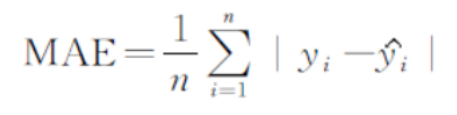

均方误差  
求误差的平方和，这也就意味着均方误差相比于平均绝对误差更敏感，更容易波动  
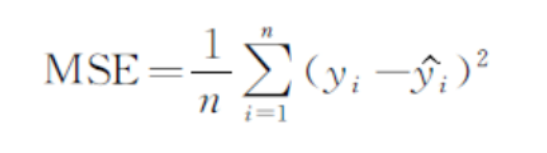  

均方根误差  
对均方误差进行开平方运算（在MSE上加个根号），这样做既能保证单位的统一，同时又保留了均方误差的特性  

绝对系数$R^2$ (Residuals-Squared)  
MAE和RMSE有个缺点：没有上限。假如 MAE 算出来是 5000，这到底是好还是坏？如果是预测房价，差 5000 块简直是神仙模型；但如果是预测你明天的午餐费，差 5000 块就是灾难。  
起到统一度量衡的作用  
$R^2 = 1.0$：完美预言家，100% 预测正确  
$R^2$ 在 0 到 1 之间：越接近 1 越好（比如 0.8 说明模型很优秀）。  
$R^2 = 0$：预测效果差  
$R^2 < 0$ (负数)：预测效果很差  

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = np.array([100, 150, 200, 250, 300])

y_pred = np.array([105, 145, 200, 270, 320])

mae = mean_absolute_error(y_true, y_pred)
print(f"1. MAE (平均绝对误差): {mae:.2f} 万元")

mse = mean_squared_error(y_true, y_pred)
print(f"2. MSE (均方误差): {mse:.2f}")

rmse = np.sqrt(mse)
print(f"3. RMSE (均方根误差): {rmse:.2f} 万元")

r2 = r2_score(y_true, y_pred)
print(f"4. R² 分数 (决定系数): {r2:.4f}")